## Importing Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Beijing Air Quality Data

In [ ]:
air_qulaity_data = pd.read_csv("/content/Beijing_Air_Quality.csv")
air_qulaity_data.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,WNW,2.0,Wanshouxigong
1,2,2013,3,1,1,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,WNW,4.4,Wanshouxigong
2,3,2013,3,1,2,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,WNW,4.7,Wanshouxigong
3,4,2013,3,1,3,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,NW,2.6,Wanshouxigong
4,5,2013,3,1,4,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,WNW,2.5,Wanshouxigong


## Data Pre-processing

### Dataset Information

In [ ]:
print("Dataset Information")
air_qulaity_data.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


### Missing Values

In [ ]:
print("Missing Values")
air_qulaity_data.isnull().sum()

Missing Values


,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,8739
PM10,6449
SO2,9021
NO2,12116
CO,20701


In [ ]:
# Selecting only numerical columns
numerical_columns = air_qulaity_data.select_dtypes(include=['number']).columns

# Replacing missing values with the mean of each numerical column
air_qulaity_data[numerical_columns] = air_qulaity_data[numerical_columns].fillna(
    air_qulaity_data[numerical_columns].mean()
)

In [ ]:
# Replacing missing values in 'wd' with the mode
air_qulaity_data['wd'] = air_qulaity_data['wd'].fillna(
    air_qulaity_data['wd'].mode()[0]
)

### Replacing Missing Values with Mean

In [ ]:
air_qulaity_data.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


### Dataset Shape

In [ ]:
print("Dataset Shape")
air_qulaity_data.shape

Dataset Shape


(420768, 18)

## Exploratory Data Analysis (EDA)

### Descriptive Statistics

In [ ]:
print("Descriptive Statistics")
air_qulaity_data.describe()

Descriptive Statistics


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,79.978679,91.066422,21.417257,34.618463,1131.283304,55.760484,11.430729,10.469162,13.787240,0.820624,1.245914
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,21.000000,36.000000,3.000000,24.000000,500.000000,12.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,57.000000,84.000000,8.000000,45.000000,900.000000,47.000000,14.500000,1010.400000,3.000000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,109.000000,144.000000,19.000000,70.000000,1500.000000,80.000000,23.200000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


### Distribution of Numerical Variables

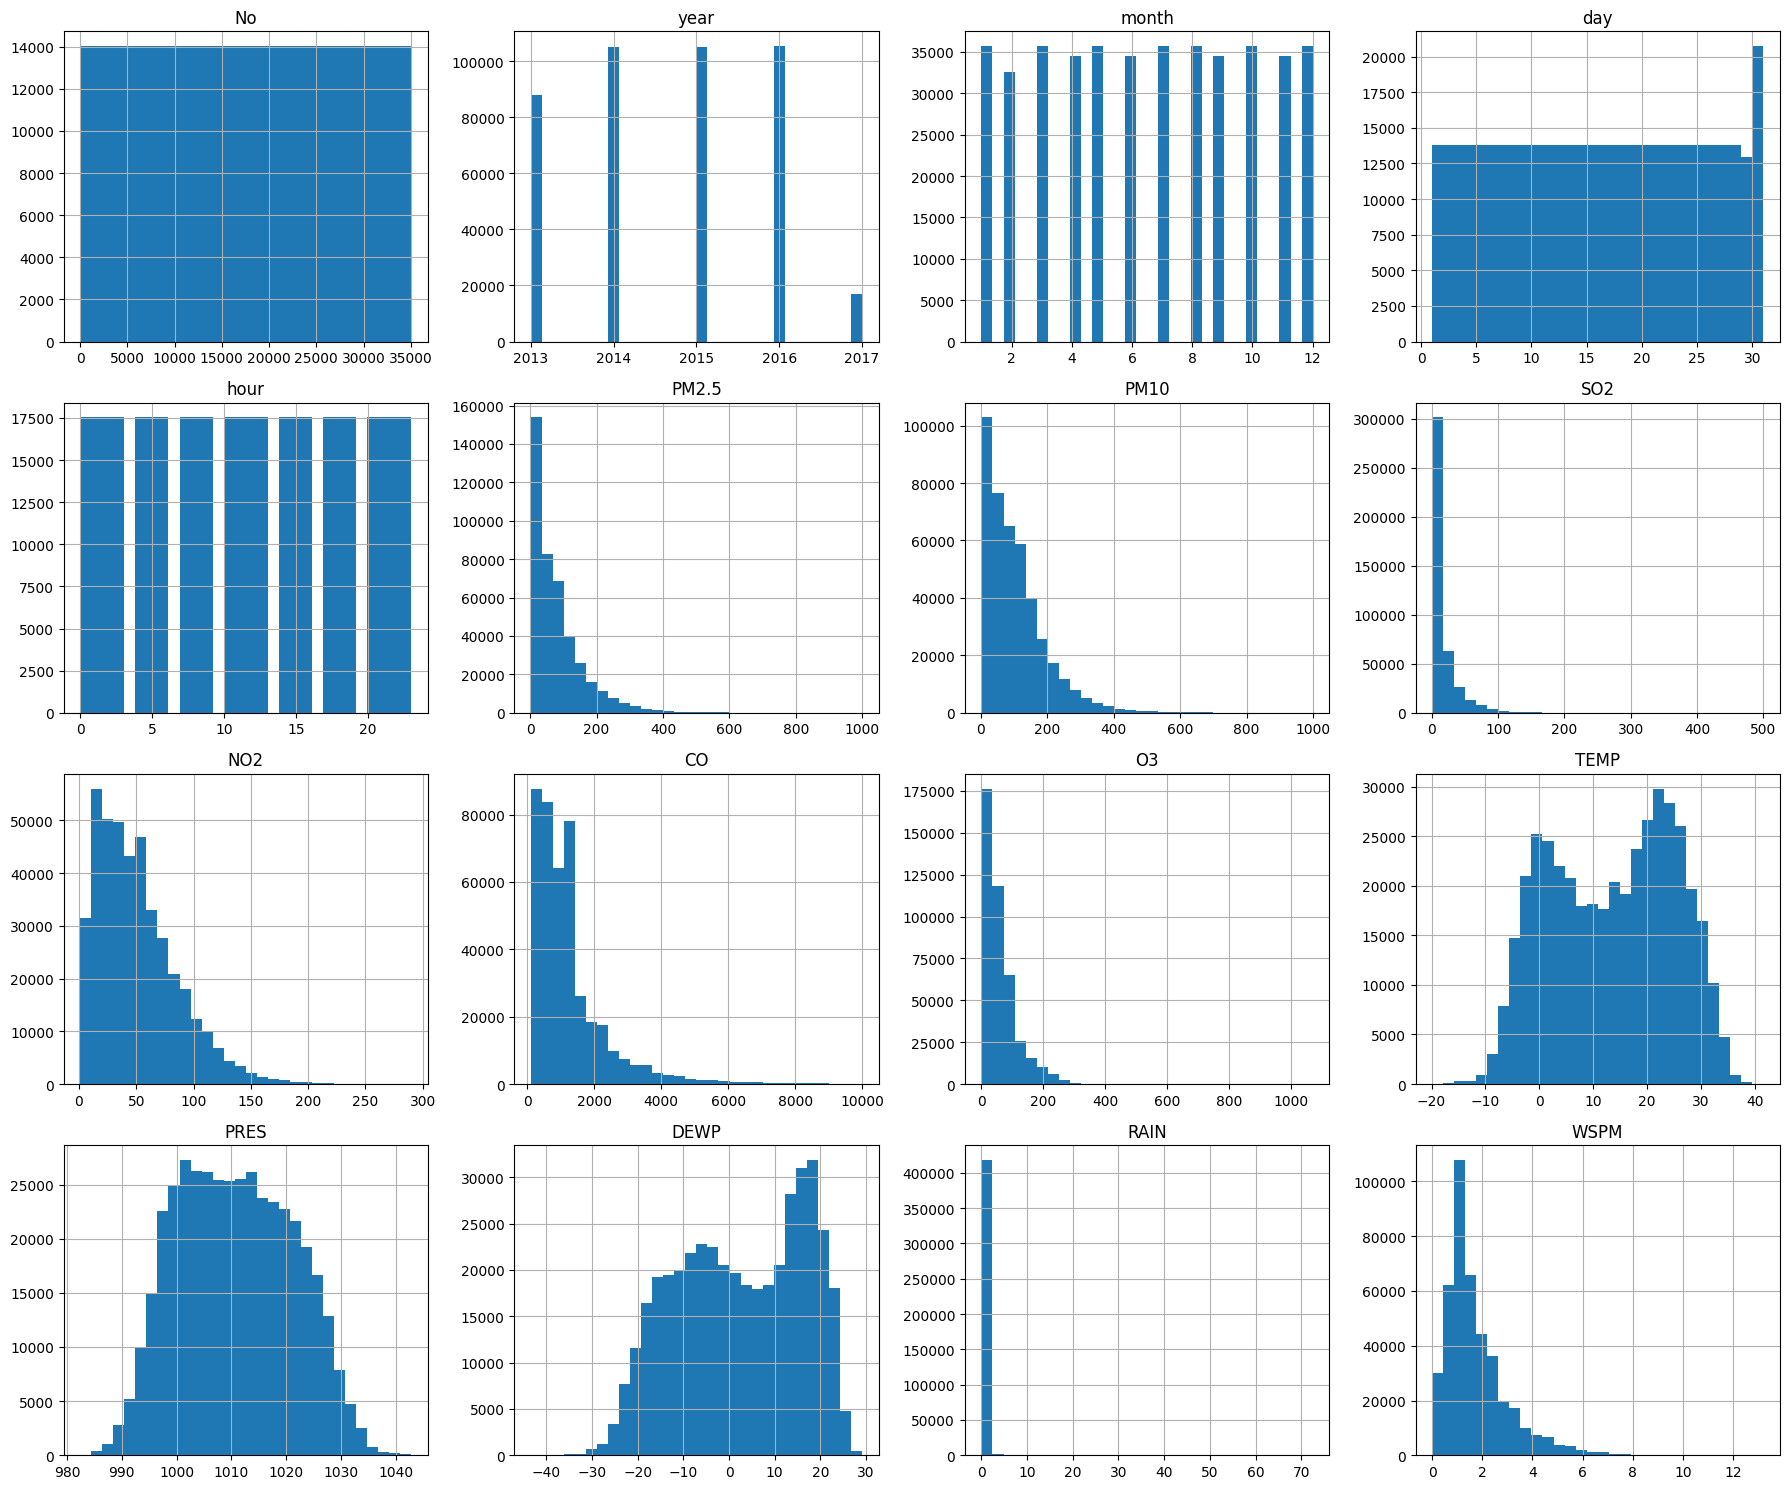

In [ ]:
air_qulaity_data.hist(figsize=(18,15), bins=30)

plt.tight_layout()
plt.show()

### Correlation Heatmap

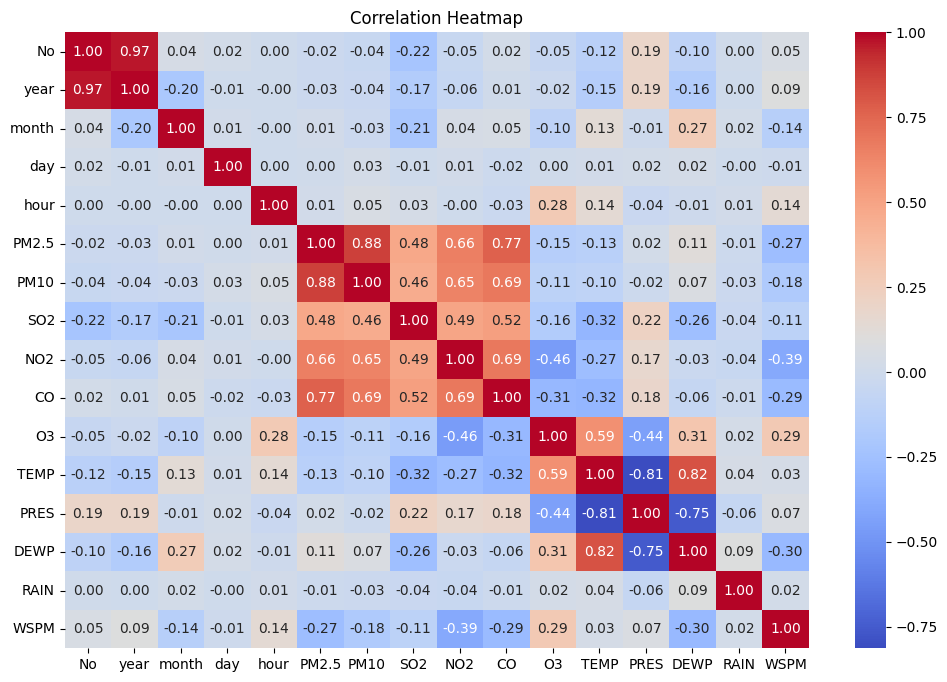

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    air_qulaity_data.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Boxplots (Outlier Detection)

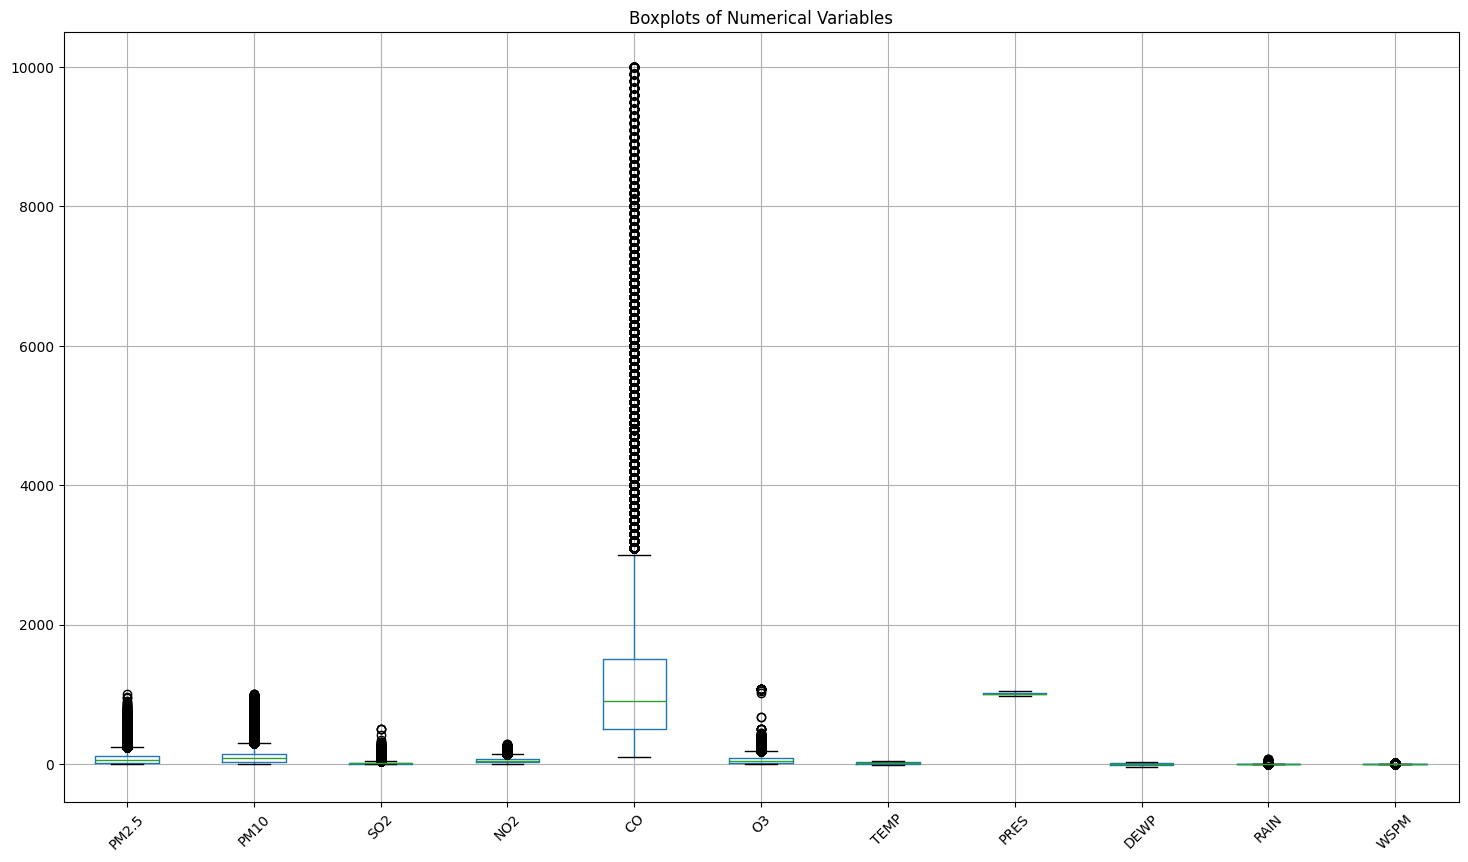

In [ ]:
numerical_columns = [
    'PM2.5','PM10','SO2','NO2','CO',
    'O3','TEMP','PRES','DEWP','RAIN','WSPM'
]

plt.figure(figsize=(18,10))

air_qulaity_data[numerical_columns].boxplot(rot=45)

plt.title("Boxplots of Numerical Variables")
plt.show()

### PM2.5 Distribution

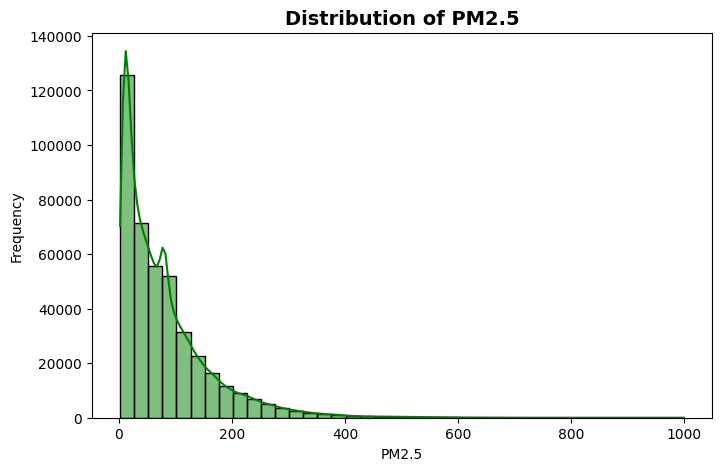

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    air_qulaity_data["PM2.5"],
    bins=40,
    kde=True,
    color="green"
)

plt.title("Distribution of PM2.5", fontsize=14, fontweight='bold')
plt.xlabel("PM2.5")
plt.ylabel("Frequency")

plt.show()

### Average PM10 by Monitoring Station

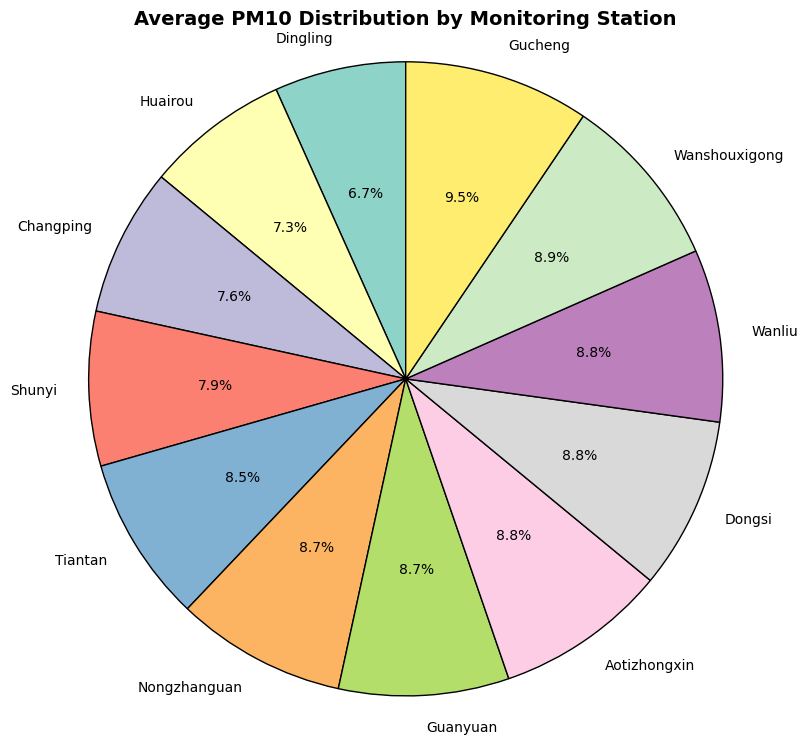

In [ ]:
# Calculating average PM10 for each station
pm10_station = air_qulaity_data.groupby("station")["PM10"].mean().sort_values()

colors = plt.cm.Set3(range(len(pm10_station)))

plt.figure(figsize=(9,9))

plt.pie(
    pm10_station,
    labels=pm10_station.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor':'black'}
)

plt.title("Average PM10 Distribution by Monitoring Station", fontsize=14, fontweight='bold')

plt.axis('equal')

plt.show()

### Monthly PM10 Trend

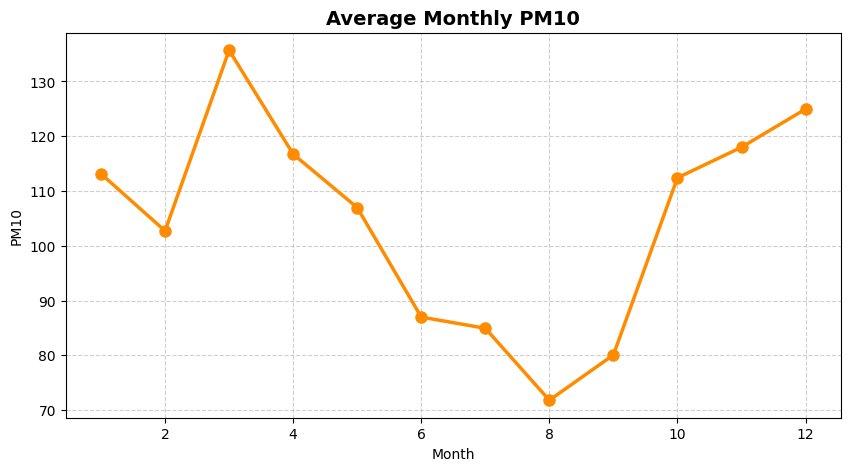

In [ ]:
monthly_pm10 = air_qulaity_data.groupby("month")["PM10"].mean()

plt.figure(figsize=(10,5))

monthly_pm10.plot(
    marker="o",
    color="darkorange",
    linewidth=2.5,
    markersize=8
)

plt.title("Average Monthly PM10", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("PM10")

plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

### Temperature Trend

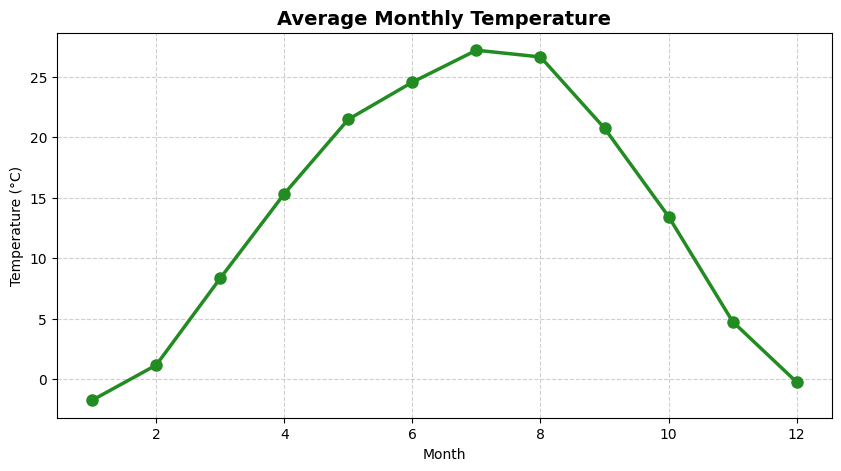

In [ ]:
monthly_temp = air_qulaity_data.groupby("month")["TEMP"].mean()

plt.figure(figsize=(10,5))

monthly_temp.plot(
    marker="o",
    color="forestgreen",
    linewidth=2.5,
    markersize=8
)

plt.title("Average Monthly Temperature", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

### Wind Direction Frequency


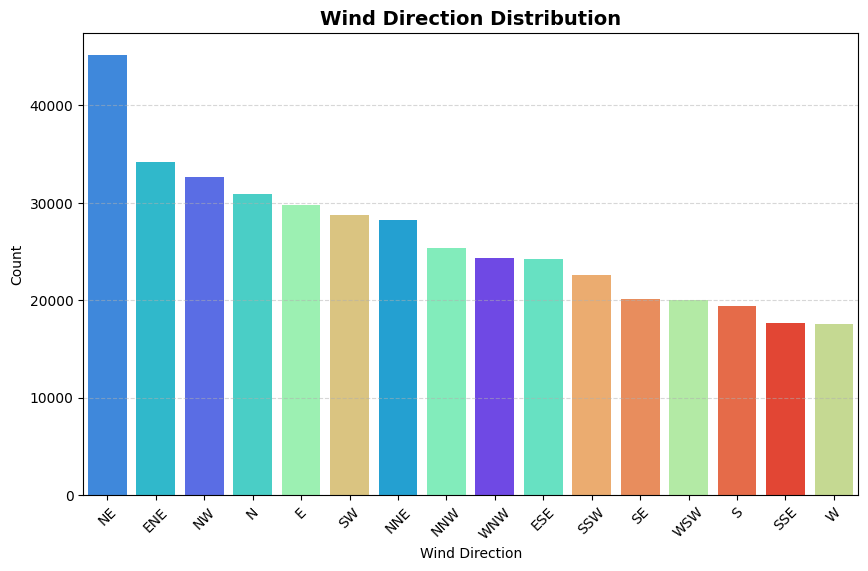

In [ ]:
order = air_qulaity_data["wd"].value_counts().index
colors = sns.color_palette("rainbow", n_colors=len(order))

plt.figure(figsize=(10,6))

sns.countplot(
    data=air_qulaity_data,
    x="wd",
    order=order,
    hue="wd",
    palette=colors,
    legend=False
)

plt.xticks(rotation=45)

plt.title("Wind Direction Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Wind Direction")
plt.ylabel("Count")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Scatter Plot for PM2.5 vs PM10

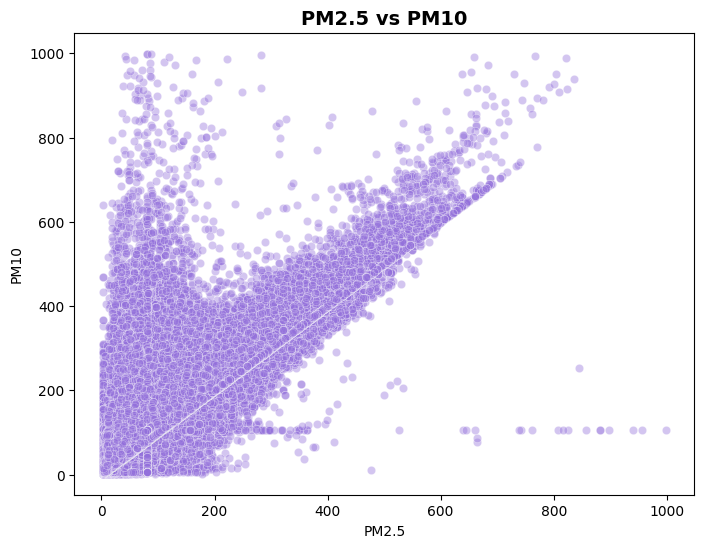

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=air_qulaity_data,
    x="PM2.5",
    y="PM10",
    color="mediumpurple",
    alpha=0.4
)

plt.title("PM2.5 vs PM10", fontsize=14, fontweight='bold')
plt.show()

### Pairplot for Selected Variables

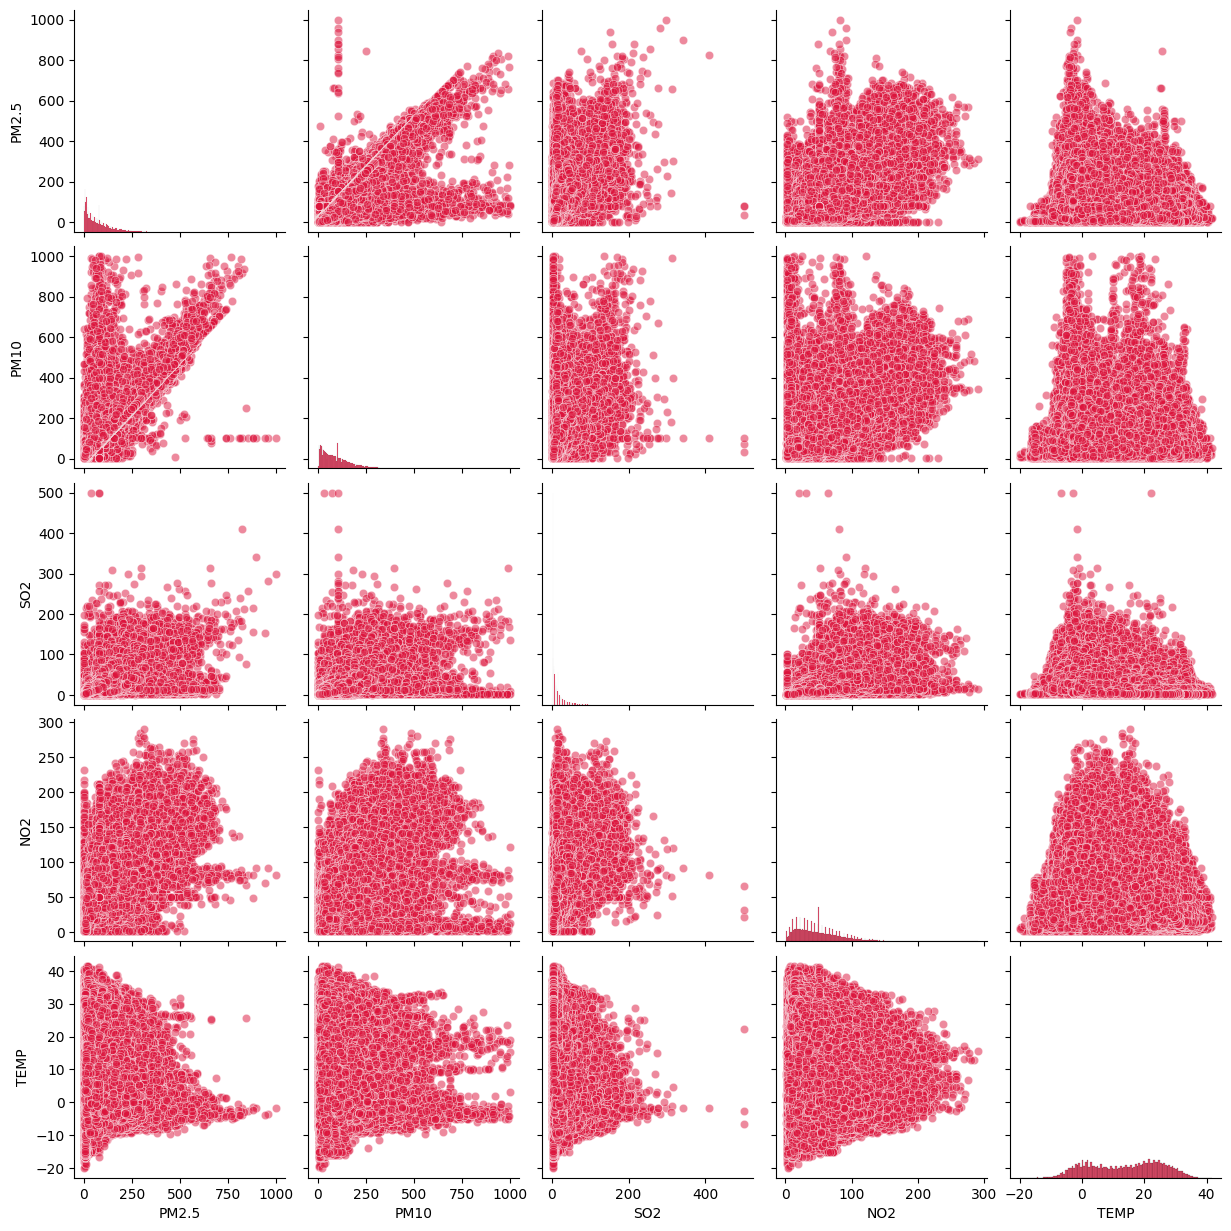

In [ ]:
selected_columns = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "TEMP"
]

sns.pairplot(
    air_qulaity_data[selected_columns],
    plot_kws={'color':'crimson', 'alpha':0.5},
    diag_kws={'color':'crimson'}
)

plt.show()

## Model Implementation

### Feature Selection

In [ ]:
# Features
X = air_qulaity_data[['PM10', 'SO2', 'NO2', 'CO', 'O3',
                      'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']]

# Target
y = air_qulaity_data['PM2.5']

### Train-Test Splitting

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(336614, 10)
(84154, 10)


### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2 :", lr_r2)

Linear Regression
MAE : 20.605530690056543
RMSE: 31.99162919697099
R2 : 0.8404462836040565


### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree")
print("MAE :", dt_mae)
print("RMSE:", dt_rmse)
print("R2 :", dt_r2)

Decision Tree
MAE : 16.703678556208807
RMSE: 29.12519549175992
R2 : 0.8677572390631654


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2 :", rf_r2)

Random Forest
MAE : 12.244609382166635
RMSE: 20.23798346552851
R2 : 0.9361488559508366


### XGBoost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    n_estimators=100
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2 :", xgb_r2)

XGBoost
MAE : 13.553577054033585
RMSE: 21.54827270441822
R2 : 0.927613240394578


### Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,20.605531,31.991629,0.840446
1,Decision Tree,16.703679,29.125195,0.867757
2,Random Forest,12.244609,20.237983,0.936149
3,XGBoost,13.553577,21.548273,0.927613


In [ ]:
# Find the row with the highest R² Score
best_model_row = results.loc[results["R2 Score"].idxmax()]

print("Best Model:")
print(best_model_row)

Best Model:
Model       Random Forest
MAE             12.244609
RMSE            20.237983
R2 Score         0.936149
Name: 2, dtype: object


### Saving the Best Model

In [ ]:
import joblib

joblib.dump(rf, "best_air_quality_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
joblib.dump(rf, "scaler.pkl")

print("Scaler saved successfully!")